In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías y de `listings_train.csv`/`listings_test.csv`, el split guardado por `03_model_baseline.ipynb` (mismo `random_state=42`, para que los resultados sean comparables entre notebooks).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/malaga/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/malaga/listings_test.csv")
train_df.shape, test_df.shape

((6993, 81), (1749, 81))

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal ya llegó a R²=0.42: el mejor resultado lineal de las cuatro ciudades tras Barcelona/Madrid. Con eso en mente, se prueban los mismos cuatro tipos de modelo que en las otras tres ciudades:

- **Ridge**: versión regularizada de la regresión lineal del baseline. Sirve para ver cuánto más se le puede sacar a un modelo lineal antes de pasar a algo no lineal.
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest con aleatoriedad extra al elegir los cortes de cada árbol. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`, igual que en las otras ciudades). Admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge). Para Hist Gradient Boosting no se imputa nada, para conservar la información de "sin reviews todavía" que aporta el propio `NaN`.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb`. A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`.

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

74

### 3.2 X e y

`train_df`/`test_df` ya son el split guardado por el baseline, así que aquí no hace falta volver a dividir nada.

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((6993, 74), (1749, 74))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

43

### 3.4 Nulos: sin tratar todavía

`review_scores_rating`, `listing_age_days` y `days_since_last_review` se quedan con sus `NaN` tal cual. Cada `Pipeline` de la sección 4 decide si los imputa o los deja pasar al modelo.

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      622
listing_age_days          622
days_since_last_review    622
dtype: int64

## 4. Pipelines

Un `Pipeline` por modelo, con el preprocesado que necesita cada uno.

### 4.1 Objetivo: `log1p(price)`

Mismo criterio que en el baseline: se entrena sobre `log1p(price)`, no sobre `price` directamente.

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6.

## 5. Entrenamiento y comparación entre modelos

Los cuatro pipelines evaluados por validación cruzada sobre el train (sin tocar el test todavía).

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,146.57,63.32,0.42,26.87
Random Forest,123.32,50.95,0.59,23.10
Extra Trees,120.88,50.67,0.61,23.05
Hist Gradient Boosting,119.60,49.69,0.62,22.43


### 5.3 Interpretación

**Aquí sí hay un salto claro de lineal a no lineal**, más parecido a Barcelona/Madrid que a Valencia: Ridge se queda en R²=0.42, mientras que los tres modelos de árboles saltan a 0.59-0.62 (Random Forest 0.59, Extra Trees 0.61, Hist Gradient Boosting 0.62, el mejor de los cuatro con hiperparámetros por defecto). Coherente con lo visto en `03_model_baseline.ipynb`: `accommodates` tiene aquí una correlación de Pearson relativamente fuerte (0.50) pero el modelo lineal sigue sin capturar relaciones no monótonas como la de `minimum_nights`, que un modelo de árboles sí puede aprovechar.

Como en las otras ciudades, esta comparación no decide nada: los tres modelos de árboles se afinan igualmente en la sección 6, no solo el que gane aquí por poco.

## 6. Ajuste de hiperparámetros

Se afinan Random Forest, Extra Trees y Hist Gradient Boosting con `RandomizedSearchCV` y validación cruzada.

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`.

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.749930937017926


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7444281367432449


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 63, 'model__max_iter': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__l2_regularization': 1.0}
0.768410958221816


### 6.4 Resumen

Los tres suben de R²≈0.59-0.62 (sin afinar, en euros) a **R²≈0.74-0.77 en escala logarítmica** con los mejores hiperparámetros. Ojo: este número está en la escala de `log1p(price)`, no es directamente comparable con la tabla en euros de la sección 5. La comparación justa en euros se hace en la sección 7.

## 7. Elegir el modelo final

Los tres modelos ya afinados, comparados entre sí (seguimos sin tocar el test).

### 7.1 Comparar en euros con los mejores hiperparámetros

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(2)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),122.03,50.32,0.60,22.75
Extra Trees (tuned),120.96,50.39,0.61,22.77
Hist Gradient Boosting (tuned),117.18,49.42,0.63,22.47


### 7.2 Decisión

A diferencia de Valencia (donde quedó un empate técnico 2-2), aquí **Hist Gradient Boosting gana claramente en las cuatro métricas**: RMSE (117.18), MAE (49.42), R² (0.631) y MAPE (22.47%), por delante de Extra Trees (120.96 / 50.39 / 0.607 / 22.77) y Random Forest (122.03 / 50.32 / 0.601 / 22.75). Se decide por **Hist Gradient Boosting**, igual que en Barcelona/Madrid/Valencia, aquí sin ningún matiz que discutir: gana por sí solo.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=1.0,
                                               max_depth=5, max_iter=200,
                                               max_leaf_nodes=63,
                                               random_state=42))])

## 8. Evaluación en test

El modelo elegido en la sección 7, entrenado sobre todo el train y evaluado una única vez sobre el test.

### 8.1 Evaluar en test, por primera y única vez

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(154.670915347163),
 'MAE': 52.19319678073402,
 'R2': 0.5655606506519071,
 'MAPE': np.float64(22.293957420282098)}

### 8.2 Train vs. test: ¿hay sobreajuste?

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,81.793305,36.390189,0.821217,16.366080
Test,154.670915,52.193197,0.565561,22.293957


Aquí sí aparece el patrón "normal" (a diferencia de Valencia, donde salía al revés): el modelo acierta bastante más de cerca en train (MAE 36.4€, R²=0.82) que en test (MAE 52.2€, R²=0.57). La brecha es real, pero tiene una causa identificable y no es un fallo del pipeline: `y_train` tiene una asimetría de 6.4 (máximo 4775€, la villa más cara de toda la EDA) y `y_test` de 8.8 (máximo 4573€): **el test quedó, por puro azar del split, con una cola relativa todavía más pronunciada que el train** (más casos extremos en proporción a su tamaño, aunque el valor máximo absoluto sea algo menor). Como RMSE y R² penalizan los errores grandes al cuadrado, esto castiga más al test de lo que un `max_depth=5` por sí solo explicaría. Es una combinación de algo de sobreajuste normal en un modelo de árboles bien afinado y el mismo tipo de varianza de split ya documentado en Valencia frente a una variable con cola larga: un matiz a tener en cuenta en `05_model_evaluation.ipynb`.

## 9. Comparación con el baseline

El resultado de la sección 8 frente al listón de `03_model_baseline.ipynb` (regresión lineal: R²=0.42, MAE≈67.4€).

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 178.70, "MAE": 67.36, "R2": 0.42, "MAPE": 26.82},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 178.7,
  'MAE': 67.36,
  'R2': 0.42,
  'MAPE': 26.82},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(154.670915347163),
  'MAE': 52.19319678073402,
  'R2': 0.5655606506519071,
  'MAPE': np.float64(22.293957420282098)}}

Mejora clara en las cuatro métricas, la más marcada de las cuatro ciudades en términos relativos: **RMSE de 178.7€ a 154.7€, MAE de 67.4€ a 52.2€, R² de 0.42 a 0.57, MAPE de 26.8% a 22.3%**. Confirma la lectura de la sección 5.3: en Málaga hay bastante más terreno no lineal por explotar del que sugería el propio baseline lineal, y un modelo de árboles bien afinado lo aprovecha con más margen que en Valencia.

## 10. Importancia de variables

Igual que en las otras ciudades: `HistGradientBoostingRegressor` no tiene `feature_importances_`, así que se usa **permutation importance**.

### 10.1 Calcular la importancia

Se calcula sobre el test, para medir qué variables son importantes de cara a generalizar.

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.258832
accommodates                      0.179964
calculated_host_listings_count    0.103499
latitude                          0.050770
longitude                         0.047472
bathrooms                         0.043365
n_amenities                       0.041349
availability_365                  0.027951
host_entire_homes_ratio           0.025062
room_type_Entire home/apt         0.024663
bedrooms                          0.024448
has_pool                          0.024105
review_scores_rating              0.011040
estimated_occupancy_l365d         0.010930
distance_to_center_km             0.010261
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

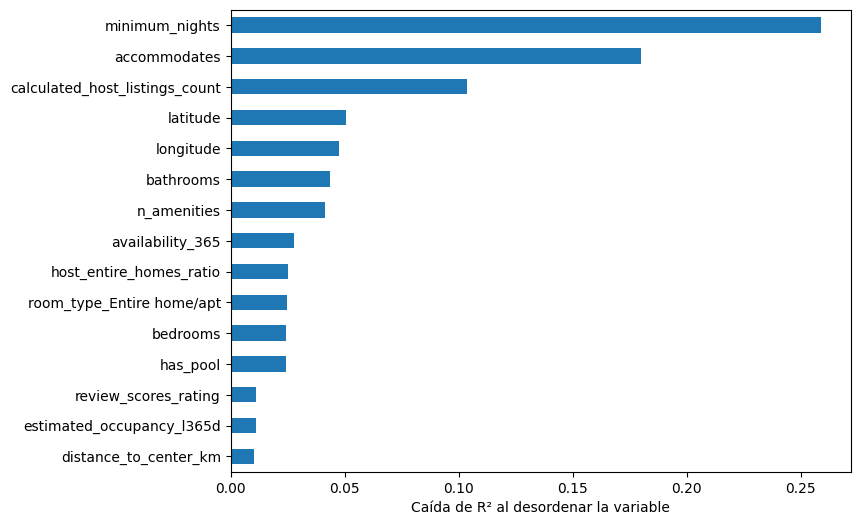

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

**`minimum_nights` vuelve a dominar** (caída de R² de 0.259), igual que en las otras tres ciudades, seguido de `accommodates` (0.180). El tercer puesto rompe el patrón: no es `room_type_Entire home/apt` (que aquí cae hasta el 0.025), sino **`calculated_host_listings_count`** (0.103): coherente con el hallazgo de `02_feature_engineering.ipynb` de que Málaga es el mercado más profesionalizado de las cuatro ciudades (mediana de 6 anuncios por host), donde saber cuántos anuncios gestiona un host aporta bastante más señal que en las otras.

Otro matiz propio de Málaga: `latitude` (0.051) y `longitude` (0.047) entran con peso propio en el top 15, por delante incluso de `bathrooms` (0.043), algo que no ocurre en las otras ciudades. Tiene sentido a la luz de la sección 5.2 de `02_feature_engineering.ipynb`: `district_*` y `neighbourhood_price_encoded` se calcularon sobre la misma columna (`neighbourhood_cleansed`, sin nivel de barrio más fino), así que el modelo recurre a las coordenadas exactas para capturar variación geográfica más fina de la que esas dos columnas, redundantes entre sí, pueden ofrecer por separado. `has_pool` (0.024) entra también en el top 15, confirmando el hallazgo de la EDA.

### 10.3 SHAP: cuánto y en qué dirección

Se calcula sobre el test, igual que la importancia por permutación.

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

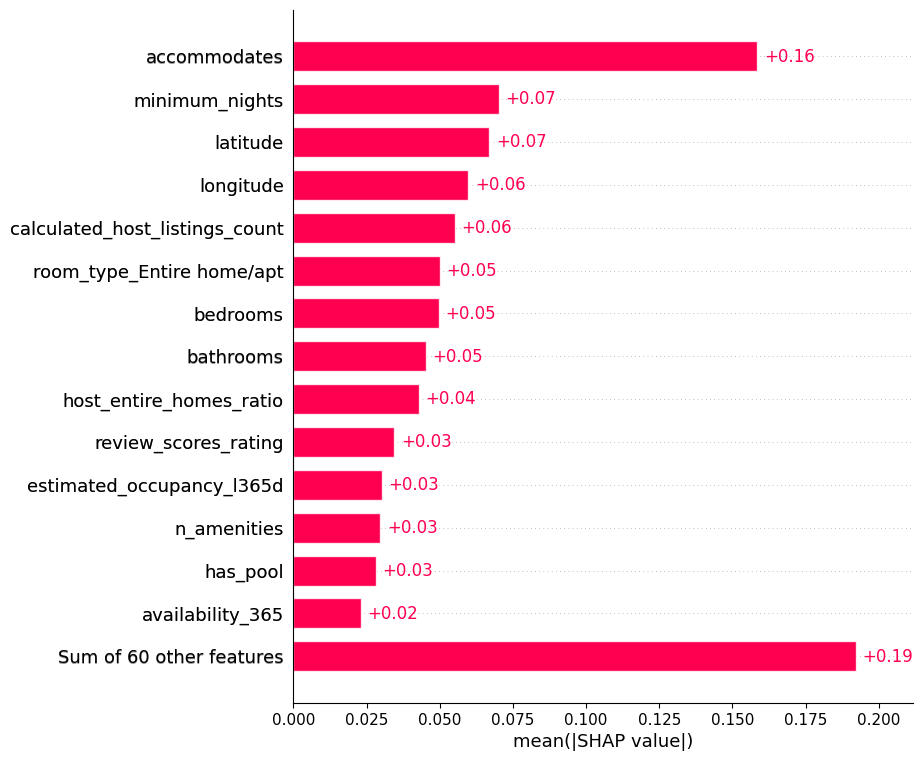

In [22]:
shap.plots.bar(shap_values, max_display=15)

El orden cambia respecto a la importancia por permutación, aunque las mismas variables dominan: SHAP pone a **`accommodates`** en primer lugar (0.159, por delante de `minimum_nights`, 0.070), y **`latitude`/`longitude`** (0.067/0.060) suben al tercer y cuarto puesto, por delante de `calculated_host_listings_count` (0.055). Ambos métodos coinciden en que el tamaño, la estancia mínima, la ubicación exacta y cuántos anuncios gestiona el host son las cuatro piezas clave, aunque no en el orden exacto: la señal geográfica de `latitude`/`longitude` es, con los dos métodos, más fuerte que la de `neighbourhood_price_encoded` o cualquier `district_*`, que no entran en el top 15 de ninguno de los dos.

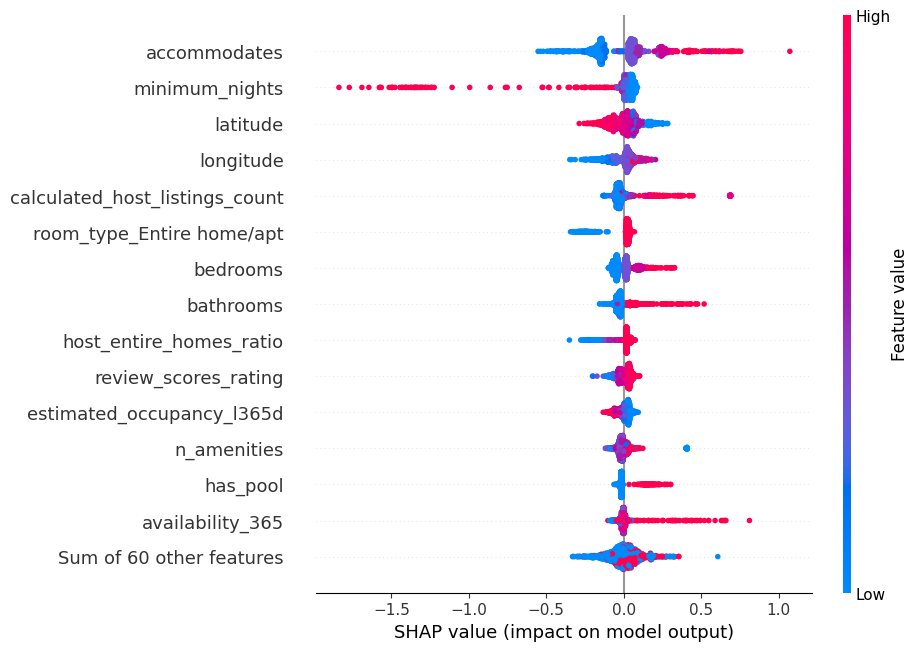

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

Aquí se ve la dirección: en `accommodates` (correlación valor↔SHAP de 0.93), `room_type_Entire home/apt` (0.99) y `bedrooms`/`bathrooms` (0.94/0.91) el patrón es el esperado: valores altos empujan el precio hacia arriba con fuerza y de forma muy consistente. `minimum_nights` (-0.82) va al revés, el mismo patrón de "alquiler de larga estancia más barato por noche" que en las otras ciudades. `latitude` (-0.77) y `longitude` (0.73) muestran una relación direccional clara pero, al ser coordenadas sin un "más alto es mejor" intuitivo, reflejan sobre todo que ciertas zonas del mapa (las villas de las afueras identificadas en la EDA) quedan sistemáticamente a un lado de esas coordenadas. `calculated_host_listings_count` (0.71) empuja hacia arriba cuando es alto, consistente con la sección 10.2.

### 10.4 Un ejemplo concreto

Se elige un anuncio de precio cercano a la mediana del test, y donde además el modelo acierta bastante.

Precio real: 154.00€, predicho: 153.11€


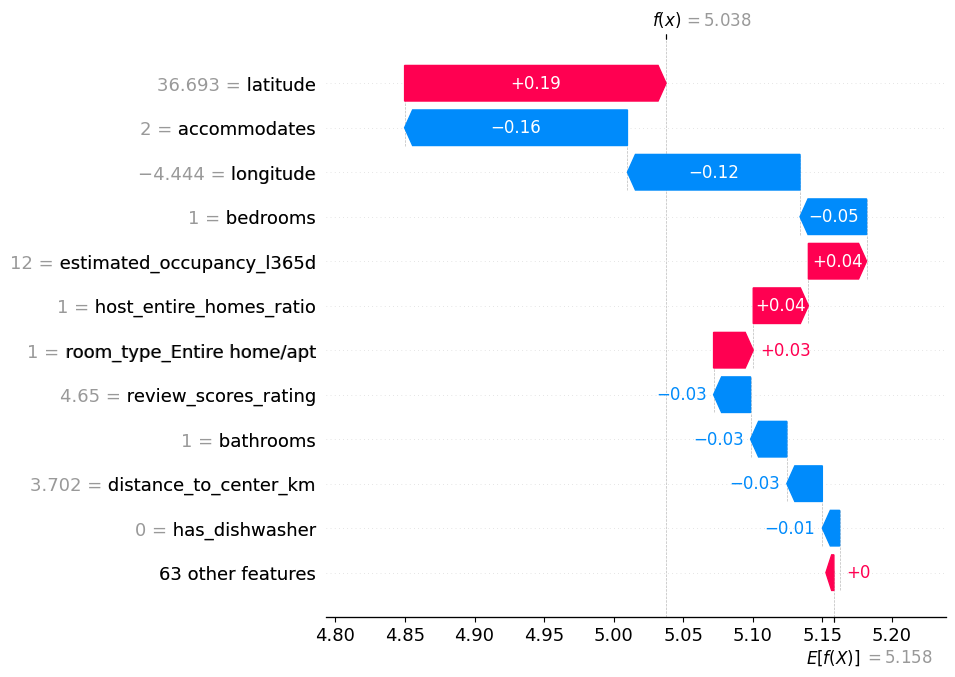

In [24]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`) equivale a unos 173€. Para este anuncio en concreto (piso entero para 2 personas, 1 dormitorio, 1 baño, `minimum_nights=2`, disponible 293 días al año, gestionado por un host con 58 anuncios, en una zona algo por debajo de la media de precio): la ubicación exacta (`latitude`) empuja el precio hacia arriba, mientras que `accommodates=2` y `longitude` lo empujan hacia abajo con más fuerza, hasta llegar a la predicción final de 153€ (el precio real era 154€, un acierto casi exacto). El mismo tipo de desglose que en las otras ciudades, con un matiz propio de Málaga: aquí son las coordenadas, no el barrio codificado, las que más pesan en el ajuste fino de la ubicación.

## 11. Guardar el modelo

Guardar el modelo final entrenado (con `joblib`) en `models/malaga/`, para que `05_model_evaluation.ipynb` lo cargue directamente.

### 11.1 El modelo

In [25]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/malaga/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/malaga/price_model.pkl']

### 11.2 Metadatos

Se guarda todo lo que `05_model_evaluation.ipynb` necesitará saber sin releer este notebook entero.

In [26]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 178.70, "MAE": 67.36, "R2": 0.42, "MAPE": 26.82},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/malaga/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-09',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Bailen-Miraflores',
  'district_Campanillas',
 

`R2_log` (0.78) es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena, bastante más alto que el R² en euros (0.57), precisamente porque en euros pesan mucho los precios extremos que se vieron en la sección 8.2. Se guarda como métrica adicional para que la app pueda mostrar una cifra de "cuánto explica el modelo" comparable entre ciudades.

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto. A diferencia de Valencia, aquí hubo un salto claro entre Ridge (R²=0.42) y los tres modelos de árboles (0.59-0.62), más parecido a Barcelona/Madrid.
2. Se afinaron los tres modelos de árboles. A diferencia de Valencia (empate técnico), **Hist Gradient Boosting ganó claramente en las cuatro métricas**.
3. El modelo final se evaluó en test una única vez.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 178.70€ | 67.36€ | 0.42 | 26.82% |
| **Hist Gradient Boosting (final)** | **154.67€** | **52.19€** | **0.57** | **22.29%** |

Mejora real y consistente sobre el baseline en las cuatro métricas: la más marcada de las cuatro ciudades en términos relativos. A diferencia de Valencia, el patrón train/test es el esperado (mejor en train), con una brecha explicada en parte por una cola de precio relativamente más pronunciada en el test que en el train (sección 8.2), no por un problema del modelo.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en que `minimum_nights` y `accommodates` son las dos variables más importantes, aunque no siempre en el mismo orden. La sorpresa de Málaga está en el resto del top: `calculated_host_listings_count` entra en tercer lugar por permutación (reflejo de ser el mercado más profesionalizado de las cuatro ciudades), y `latitude`/`longitude` pesan más que `neighbourhood_price_encoded` o cualquier `district_*` en los dos métodos: consecuencia directa de que Málaga codifica el distrito y el barrio sobre la misma columna (sección 5.2 de `02_feature_engineering.ipynb`), así que el modelo recurre a las coordenadas exactas para el matiz geográfico fino que esa redundancia no le da. `has_pool` entra en el top 15 de permutation importance, confirmando el hallazgo propio de la EDA.

### Qué queda pendiente

- El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/malaga/price_model.pkl` y `models/malaga/model_metadata.json` ya guardados aquí.
- Dado el hallazgo de la sección 8.2 (cola de precio relativamente más larga en test que en train), sería razonable que `05_model_evaluation.ipynb` revise el error específicamente en los anuncios de precio muy alto, en vez de fiarse solo del R²/RMSE agregado de un único split.
- La redundancia entre `district_*` y `neighbourhood_price_encoded` (mismo origen, sección 5.2 de `02_feature_engineering.ipynb`) no perjudicó al modelo de árboles, pero es un candidato claro a simplificar si en el futuro se quisiera un modelo lineal interpretable para Málaga.